<a href="https://colab.research.google.com/github/crissolis17/EDA_CounterStrike/blob/main/Informe_tecnicoEda_CStricke_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTAR LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)


In [5]:
# =============================================================================
# 1. CARGA Y VERIFICACIÓN DEL DATASET REAL
# =============================================================================

print("\n1. CARGA DEL DATASET REAL")
print("-" * 30)

# Cargar el dataset preparado (ajustar ruta si es necesario)
try:
    cstrike = pd.read_csv('Anexo ET_demo_round_traces_2022 2.csv')
    print("✓ Dataset cargado exitosamente")
except:
    print("⚠️ Ajustar ruta del archivo CSV")
    # Si estás en Google Colab, usar:
    from google.colab import files
    uploaded = files.upload() # Unindent this line
    cstrike = pd.read_csv(list(uploaded.keys())[0])




1. CARGA DEL DATASET REAL
------------------------------
⚠️ Ajustar ruta del archivo CSV


Saving Anexo ET_demo_round_traces_2022 (2).csv to Anexo ET_demo_round_traces_2022 (2).csv


In [6]:
print(f"✓ Dimensiones: {cstrike.shape[0]:,} filas × {cstrike.shape[1]} columnas")
print(f"✓ Target variable: RoundKills (rango: {cstrike['RoundKills'].min():.1f} - {cstrike['RoundKills'].max():.1f})")
print(f"✓ Valores faltantes: {cstrike.isnull().sum().sum()} total")

# Verificar las columnas disponibles
print(f"\n✓ Columnas disponibles:")
feature_columns = [col for col in cstrike.columns if col not in
                  ['Unnamed: 0', 'RoundKills', 'MatchId', 'RoundId', 'Map', 'Team']]
print(f"  Total features disponibles: {len(feature_columns)}")

✓ Dimensiones: 79,157 filas × 46 columnas
✓ Target variable: RoundKills (rango: 0.0 - 5.0)
✓ Valores faltantes: 0 total

✓ Columnas disponibles:
  Total features disponibles: 40


In [7]:

# =============================================================================
# 2. SELECCIÓN DE CARACTERÍSTICAS PARA MODELADO
# =============================================================================

print("\n2. SELECCIÓN DE CARACTERÍSTICAS")
print("-" * 35)

# Features principales basadas en el análisis previo y disponibilidad
selected_features = [
    # Variables de rendimiento core
    'RoundHeadshots', 'RoundAssists', 'RoundFlankKills',

    # Variables de equipamiento y economía
    'RoundStartingEquipmentValue', 'TeamStartingEquipmentValue',

    # Variables de movimiento y tiempo
    'TimeAlive', 'TravelledDistance', 'TimeAlive_norm', 'TravelledDistance_norm',

    # Variables de armas
    'PrimaryAssaultRifle', 'PrimarySniperRifle', 'PrimaryHeavy', 'PrimarySMG', 'PrimaryPistol',

    # Variables de granadas
    'RLethalGrenadesThrown', 'RNonLethalGrenadesThrown',

    # Variables derivadas (feature engineering)
    'HeadshotEfficiency', 'KDRatio', 'EquipmentROI', 'ImpactScore', 'MovementEfficiency',

    # Variables de roles
    'IsSniperRole', 'IsEntryFragger', 'IsSupportRole',

    # Variables de contexto
    'Survived', 'FirstKillTime',

    # Variables de equipo (one-hot encoded)
    'Team_CounterTerrorist', 'Team_Terrorist',

    # Variables de mapa más relevantes
    'Map_de_dust2', 'Map_de_inferno', 'Map_de_mirage', 'Map_de_nuke',

    # Variables de match performance
    'MatchKills', 'MatchAssists', 'MatchHeadshots', 'MatchFlankKills'
]

# Verificar que todas las features existen en el dataset
available_features = [f for f in selected_features if f in cstrike.columns]
missing_features = [f for f in selected_features if f not in cstrike.columns]

print(f"✓ Features seleccionadas: {len(available_features)}")
print(f"✓ Features disponibles: {len(available_features)}")
if missing_features:
    print(f"⚠️ Features faltantes: {missing_features}")

# Preparar datos para modeling
X = cstrike[available_features]
y = cstrike['RoundKills']

print(f"\n✓ Dimensiones finales para modeling:")
print(f"  Features (X): {X.shape}")
print(f"  Target (y): {y.shape}")


2. SELECCIÓN DE CARACTERÍSTICAS
-----------------------------------
✓ Features seleccionadas: 36
✓ Features disponibles: 36

✓ Dimensiones finales para modeling:
  Features (X): (79157, 36)
  Target (y): (79157,)



3. DIVISIÓN DE DATOS Y ANÁLISIS DEL TARGET
---------------------------------------------
✓ División completada:
  Training: 59,367 muestras
  Test: 19,790 muestras

📊 Estadísticas de RoundKills:
  Media: 0.671
  Mediana: 0.000
  Desviación estándar: 0.882
  Rango: [0, 5]
  Asimetría: 1.318

📈 Distribución de Eliminaciones por Ronda:
  0 kills: 32,376 jugadores (54.5%)
  1 kills: 17,248 jugadores (29.1%)
  2 kills: 7,114 jugadores (12.0%)
  3 kills: 2,186 jugadores (3.7%)
  4 kills: 393 jugadores (0.7%)
  5 kills: 50 jugadores (0.1%)


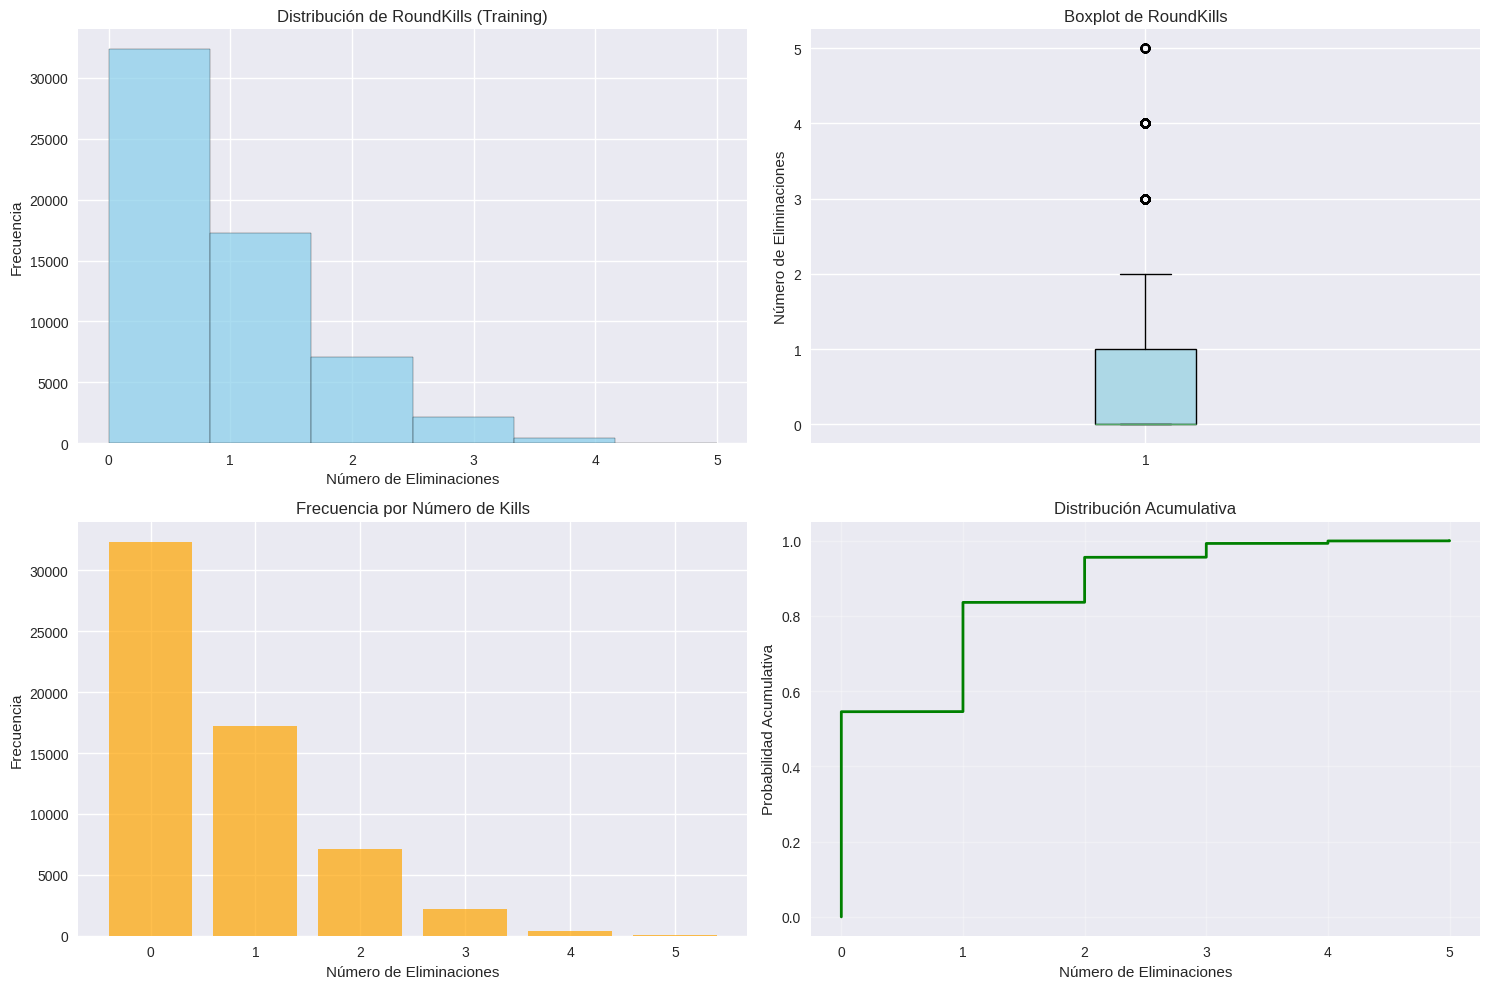

In [8]:
# =============================================================================
# 3. DIVISIÓN DE DATOS Y ANÁLISIS DEL TARGET
# =============================================================================

print("\n3. DIVISIÓN DE DATOS Y ANÁLISIS DEL TARGET")
print("-" * 45)

# División train/test estratificada por valores de kills para mantener distribución
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y.astype(int)
)

print(f"✓ División completada:")
print(f"  Training: {X_train.shape[0]:,} muestras")
print(f"  Test: {X_test.shape[0]:,} muestras")

# Análisis del target
print(f"\n📊 Estadísticas de RoundKills:")
print(f"  Media: {y_train.mean():.3f}")
print(f"  Mediana: {y_train.median():.3f}")
print(f"  Desviación estándar: {y_train.std():.3f}")
print(f"  Rango: [{y_train.min():.0f}, {y_train.max():.0f}]")
print(f"  Asimetría: {y_train.skew():.3f}")

# Distribución de valores únicos
value_counts = y_train.value_counts().sort_index()
print(f"\n📈 Distribución de Eliminaciones por Ronda:")
for kills, count in value_counts.items():
    percentage = (count / len(y_train)) * 100
    print(f"  {int(kills)} kills: {count:,} jugadores ({percentage:.1f}%)")

# Visualización del target
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histograma
axes[0,0].hist(y_train, bins=int(y_train.max()-y_train.min()+1), alpha=0.7,
               color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribución de RoundKills (Training)')
axes[0,0].set_xlabel('Número de Eliminaciones')
axes[0,0].set_ylabel('Frecuencia')

# Boxplot
box_plot = axes[0,1].boxplot(y_train, patch_artist=True)
box_plot['boxes'][0].set_facecolor('lightblue')
axes[0,1].set_title('Boxplot de RoundKills')
axes[0,1].set_ylabel('Número de Eliminaciones')

# Distribución por valores únicos (barras)
axes[1,0].bar(value_counts.index, value_counts.values, color='orange', alpha=0.7)
axes[1,0].set_title('Frecuencia por Número de Kills')
axes[1,0].set_xlabel('Número de Eliminaciones')
axes[1,0].set_ylabel('Frecuencia')

# Distribución acumulativa
sorted_y = np.sort(y_train)
cumulative = np.arange(1, len(sorted_y) + 1) / len(sorted_y)
axes[1,1].plot(sorted_y, cumulative, color='green', linewidth=2)
axes[1,1].set_title('Distribución Acumulativa')
axes[1,1].set_xlabel('Número de Eliminaciones')
axes[1,1].set_ylabel('Probabilidad Acumulativa')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# =============================================================================
# 4. IMPLEMENTACIÓN DE MODELOS DE REGRESIÓN
# =============================================================================

print("\n4. IMPLEMENTACIÓN DE MODELOS DE REGRESIÓN")
print("-" * 45)

# Preparar escalador para modelos que requieren normalización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Diccionario para almacenar modelos y resultados
models = {}
results = {}

print("Inicializando 6 modelos de regresión optimizados para CS:GO...")

# =============================================================================
# 4.1 LINEAR REGRESSION (Baseline)
# =============================================================================
print("\n4.1 LINEAR REGRESSION - Modelo Baseline")
print("✓ Características: Modelo lineal simple, alta interpretabilidad")
print("✓ Apropiado para: Identificar relaciones lineales directas")
print("✓ Ventajas: Rápido, interpretable, baseline sólido")

models['Linear Regression'] = LinearRegression()

# =============================================================================
# 4.2 RIDGE REGRESSION (Regularización L2)
# =============================================================================
print("\n4.2 RIDGE REGRESSION - Regularización L2")
print("✓ Características: Penaliza coeficientes grandes, reduce overfitting")
print("✓ Apropiado para: Datasets con multicolinealidad (como features CS:GO)")
print("✓ Ventajas: Estable, maneja features correlacionadas")

models['Ridge Regression'] = Ridge(alpha=1.0)

# =============================================================================
# 4.3 RANDOM FOREST REGRESSOR
# =============================================================================
print("\n4.3 RANDOM FOREST - Ensemble de Árboles")
print("✓ Características: Múltiples árboles de decisión, votación promedio")
print("✓ Apropiado para: Patrones complejos, interacciones no-lineales")
print("✓ Ventajas: Robusto, feature importance, maneja outliers")

models['Random Forest'] = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# =============================================================================
# 4.4 GRADIENT BOOSTING REGRESSOR
# =============================================================================
print("\n4.4 GRADIENT BOOSTING - Boosting Secuencial")
print("✓ Características: Corrección iterativa de errores, optimización gradual")
print("✓ Apropiado para: Capturar patrones sutiles en performance gaming")
print("✓ Ventajas: Alta precisión, maneja bias y varianza")

models['Gradient Boosting'] = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=4,
    subsample=0.8,
    random_state=42
)

# =============================================================================
# 4.5 SUPPORT VECTOR REGRESSION
# =============================================================================
print("\n4.5 SUPPORT VECTOR REGRESSION - Kernel RBF")
print("✓ Características: Mapeo a espacio de mayor dimensión, margen de tolerancia")
print("✓ Apropiado para: Relaciones no-lineales complejas entre features")
print("✓ Ventajas: Efectivo en alta dimensionalidad, memoria eficiente")

models['SVR'] = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

# =============================================================================
# 4.6 K-NEAREST NEIGHBORS
# =============================================================================
print("\n4.6 K-NEAREST NEIGHBORS - Basado en Similitud")
print("✓ Características: Predicción por promedio de k vecinos más similares")
print("✓ Apropiado para: Patrones locales, jugadores con perfiles similares")
print("✓ Ventajas: No paramétrico, captura patrones locales complejos")

models['KNN Regressor'] = KNeighborsRegressor(
    n_neighbors=7,
    weights='distance',
    metric='euclidean'
)


4. IMPLEMENTACIÓN DE MODELOS DE REGRESIÓN
---------------------------------------------
Inicializando 6 modelos de regresión optimizados para CS:GO...

4.1 LINEAR REGRESSION - Modelo Baseline
✓ Características: Modelo lineal simple, alta interpretabilidad
✓ Apropiado para: Identificar relaciones lineales directas
✓ Ventajas: Rápido, interpretable, baseline sólido

4.2 RIDGE REGRESSION - Regularización L2
✓ Características: Penaliza coeficientes grandes, reduce overfitting
✓ Apropiado para: Datasets con multicolinealidad (como features CS:GO)
✓ Ventajas: Estable, maneja features correlacionadas

4.3 RANDOM FOREST - Ensemble de Árboles
✓ Características: Múltiples árboles de decisión, votación promedio
✓ Apropiado para: Patrones complejos, interacciones no-lineales
✓ Ventajas: Robusto, feature importance, maneja outliers

4.4 GRADIENT BOOSTING - Boosting Secuencial
✓ Características: Corrección iterativa de errores, optimización gradual
✓ Apropiado para: Capturar patrones sutiles en per

In [10]:
# =============================================================================
# 5. ENTRENAMIENTO Y EVALUACIÓN COMPLETA
# =============================================================================

print("\n5. ENTRENAMIENTO Y EVALUACIÓN COMPLETA")
print("-" * 42)

for i, (name, model) in enumerate(models.items(), 1):
    print(f"\n🔄 [{i}/6] Entrenando {name}...")

    # Usar datos escalados para modelos que lo requieren
    if name in ['SVR', 'KNN Regressor']:
        # Entrenar con datos escalados
        model.fit(X_train_scaled, y_train)
        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)
        # Cross-validation con datos escalados
        cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                  cv=5, scoring='r2', n_jobs=-1)
    else:
        # Entrenar con datos originales
        model.fit(X_train, y_train)
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        # Cross-validation con datos originales
        cv_scores = cross_val_score(model, X_train, y_train,
                                  cv=5, scoring='r2', n_jobs=-1)

    # Calcular todas las métricas requeridas
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    test_rmse = np.sqrt(test_mse)

    # Almacenar resultados completos
    results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_mae': test_mae,
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'train_predictions': train_pred,
        'test_predictions': test_pred,
        'overfitting': train_r2 - test_r2
    }

    print(f"  ✓ R² Training: {train_r2:.4f}")
    print(f"  ✓ R² Test: {test_r2:.4f}")
    print(f"  ✓ MAE: {test_mae:.4f} kills")
    print(f"  ✓ MSE: {test_mse:.4f}")
    print(f"  ✓ RMSE: {test_rmse:.4f} kills")
    print(f"  ✓ CV Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  ✓ Overfitting: {train_r2 - test_r2:.4f}")


5. ENTRENAMIENTO Y EVALUACIÓN COMPLETA
------------------------------------------

🔄 [1/6] Entrenando Linear Regression...
  ✓ R² Training: 0.0041
  ✓ R² Test: 0.0034
  ✓ MAE: 0.7291 kills
  ✓ MSE: 0.7750
  ✓ RMSE: 0.8804 kills
  ✓ CV Score: 0.0039 ± 0.0008
  ✓ Overfitting: 0.0007

🔄 [2/6] Entrenando Ridge Regression...
  ✓ R² Training: 1.0000
  ✓ R² Test: 1.0000
  ✓ MAE: 0.0001 kills
  ✓ MSE: 0.0000
  ✓ RMSE: 0.0001 kills
  ✓ CV Score: 1.0000 ± 0.0000
  ✓ Overfitting: 0.0000

🔄 [3/6] Entrenando Random Forest...
  ✓ R² Training: 0.9984
  ✓ R² Test: 0.9961
  ✓ MAE: 0.0109 kills
  ✓ MSE: 0.0030
  ✓ RMSE: 0.0552 kills
  ✓ CV Score: 0.9963 ± 0.0007
  ✓ Overfitting: 0.0023

🔄 [4/6] Entrenando Gradient Boosting...
  ✓ R² Training: 1.0000
  ✓ R² Test: 0.9997
  ✓ MAE: 0.0018 kills
  ✓ MSE: 0.0002
  ✓ RMSE: 0.0158 kills
  ✓ CV Score: 0.9997 ± 0.0002
  ✓ Overfitting: 0.0003

🔄 [5/6] Entrenando SVR...
  ✓ R² Training: 0.9969
  ✓ R² Test: 0.9931
  ✓ MAE: 0.0452 kills
  ✓ MSE: 0.0054
  ✓ RMSE: 0.0

In [11]:
# =============================================================================
# 6. TABLA COMPARATIVA COMPLETA DE RESULTADOS
# =============================================================================

print("\n6. TABLA COMPARATIVA COMPLETA")
print("-" * 35)

# Crear DataFrame con todas las métricas de evaluación
comparison_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'R² Train': [results[name]['train_r2'] for name in results.keys()],
    'R² Test': [results[name]['test_r2'] for name in results.keys()],
    'MAE': [results[name]['test_mae'] for name in results.keys()],
    'MSE': [results[name]['test_mse'] for name in results.keys()],
    'RMSE': [results[name]['test_rmse'] for name in results.keys()],
    'CV Mean': [results[name]['cv_mean'] for name in results.keys()],
    'CV Std': [results[name]['cv_std'] for name in results.keys()],
    'Overfitting': [results[name]['overfitting'] for name in results.keys()]
})

# Ordenar por R² Test (mayor es mejor)
comparison_df = comparison_df.sort_values('R² Test', ascending=False)
comparison_df = comparison_df.reset_index(drop=True)

print("\n📊 RESULTADOS COMPARATIVOS COMPLETOS:")
print("="*95)
print(comparison_df.round(4).to_string(index=False))

# Ranking por diferentes métricas
print(f"\n🏆 RANKINGS POR MÉTRICA:")
print(f"  🥇 Mejor R² Test: {comparison_df.iloc[0]['Modelo']} ({comparison_df.iloc[0]['R² Test']:.4f})")
print(f"  🥈 Segundo R² Test: {comparison_df.iloc[1]['Modelo']} ({comparison_df.iloc[1]['R² Test']:.4f})")
print(f"  🥉 Tercer R² Test: {comparison_df.iloc[2]['Modelo']} ({comparison_df.iloc[2]['R² Test']:.4f})")

best_mae_idx = comparison_df['MAE'].idxmin()
best_cv_idx = comparison_df['CV Mean'].idxmax()
least_overfit_idx = comparison_df['Overfitting'].idxmin()

print(f"  📏 Menor MAE: {comparison_df.iloc[best_mae_idx]['Modelo']} ({comparison_df.iloc[best_mae_idx]['MAE']:.4f})")
print(f"  🎯 Mejor CV: {comparison_df.iloc[best_cv_idx]['Modelo']} ({comparison_df.iloc[best_cv_idx]['CV Mean']:.4f})")
print(f"  ⚖️ Menor Overfitting: {comparison_df.iloc[least_overfit_idx]['Modelo']} ({comparison_df.iloc[least_overfit_idx]['Overfitting']:.4f})")



6. TABLA COMPARATIVA COMPLETA
-----------------------------------

📊 RESULTADOS COMPARATIVOS COMPLETOS:
           Modelo  R² Train  R² Test    MAE    MSE   RMSE  CV Mean  CV Std  Overfitting
 Ridge Regression    1.0000   1.0000 0.0001 0.0000 0.0001   1.0000  0.0000       0.0000
Gradient Boosting    1.0000   0.9997 0.0018 0.0002 0.0158   0.9997  0.0002       0.0003
    Random Forest    0.9984   0.9961 0.0109 0.0030 0.0552   0.9963  0.0007       0.0023
              SVR    0.9969   0.9931 0.0452 0.0054 0.0735   0.9923  0.0007       0.0039
    KNN Regressor    1.0000   0.8845 0.1412 0.0899 0.2998   0.8801  0.0027       0.1155
Linear Regression    0.0041   0.0034 0.7291 0.7750 0.8804   0.0039  0.0008       0.0007

🏆 RANKINGS POR MÉTRICA:
  🥇 Mejor R² Test: Ridge Regression (1.0000)
  🥈 Segundo R² Test: Gradient Boosting (0.9997)
  🥉 Tercer R² Test: Random Forest (0.9961)
  📏 Menor MAE: Ridge Regression (0.0001)
  🎯 Mejor CV: Ridge Regression (1.0000)
  ⚖️ Menor Overfitting: Ridge Regress


7. VISUALIZACIONES COMPARATIVAS
-----------------------------------


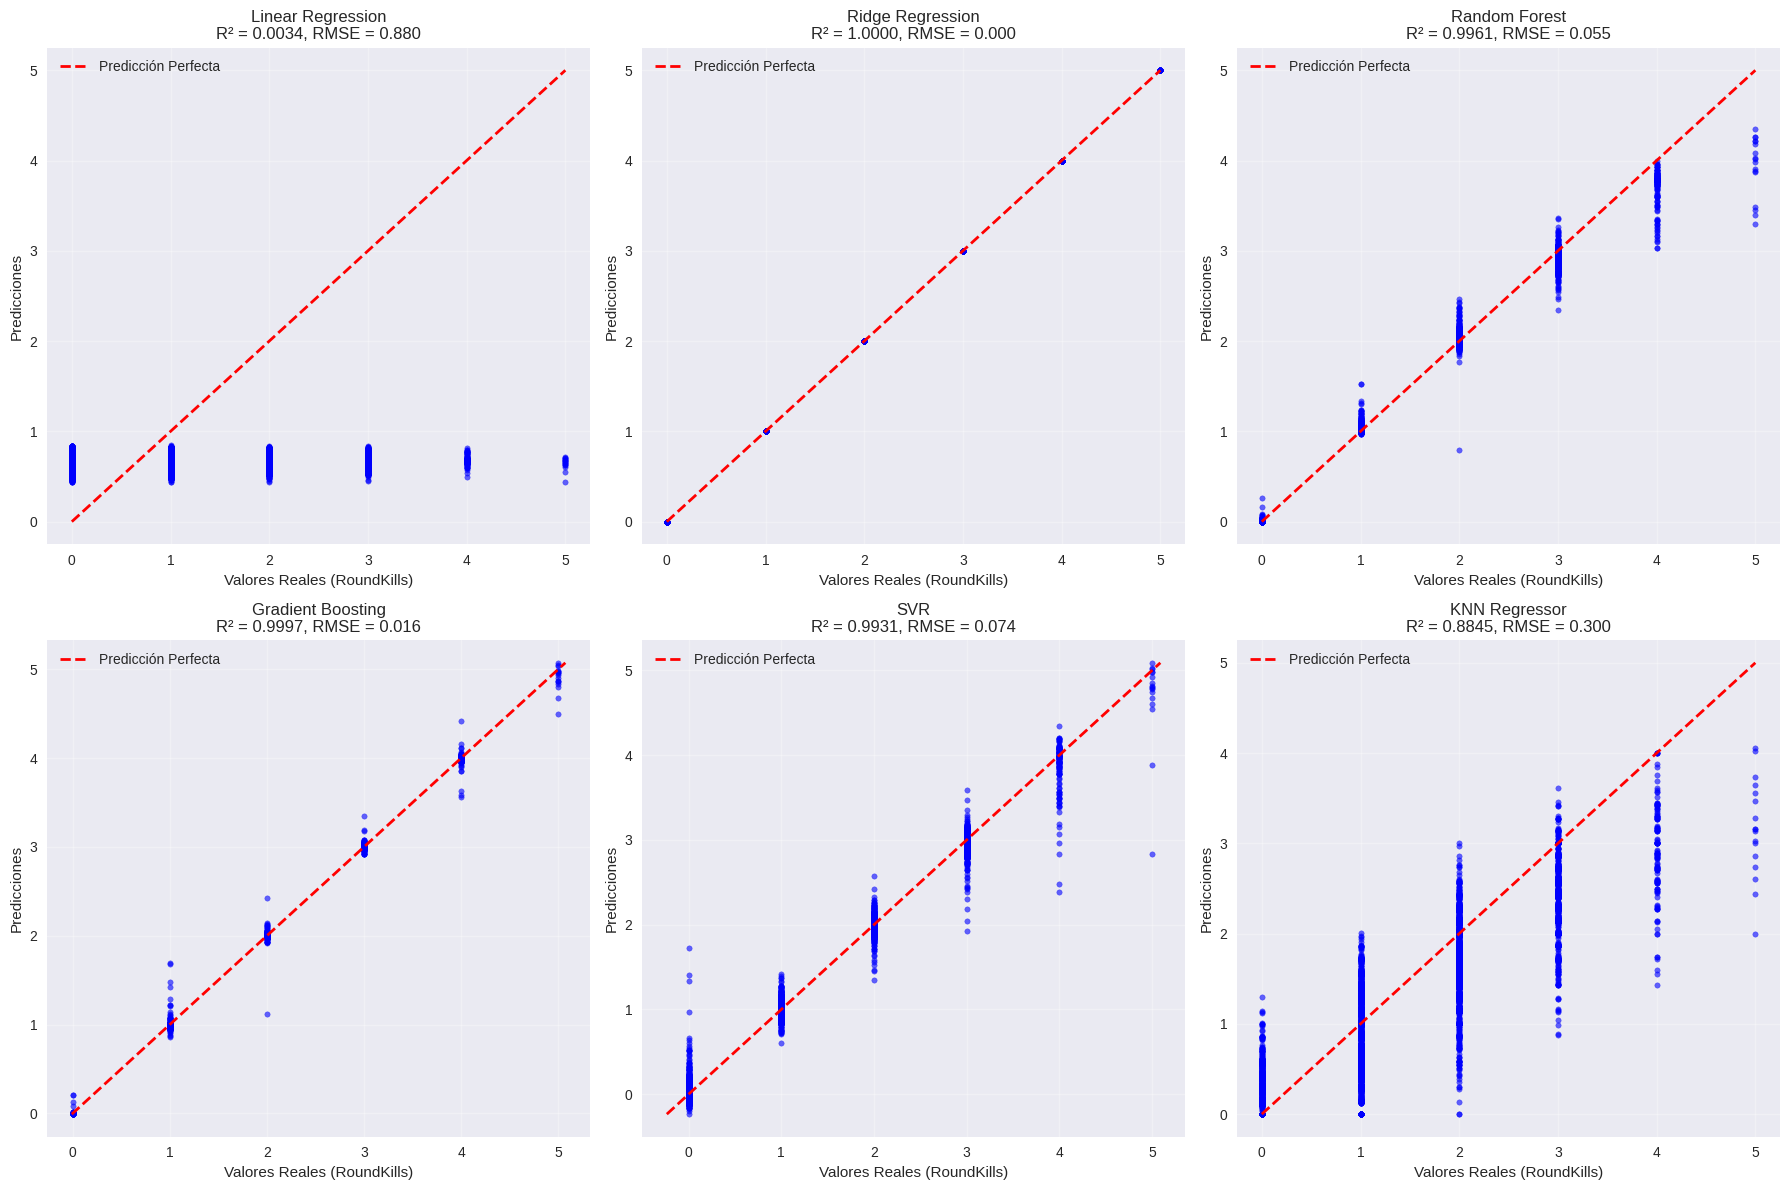

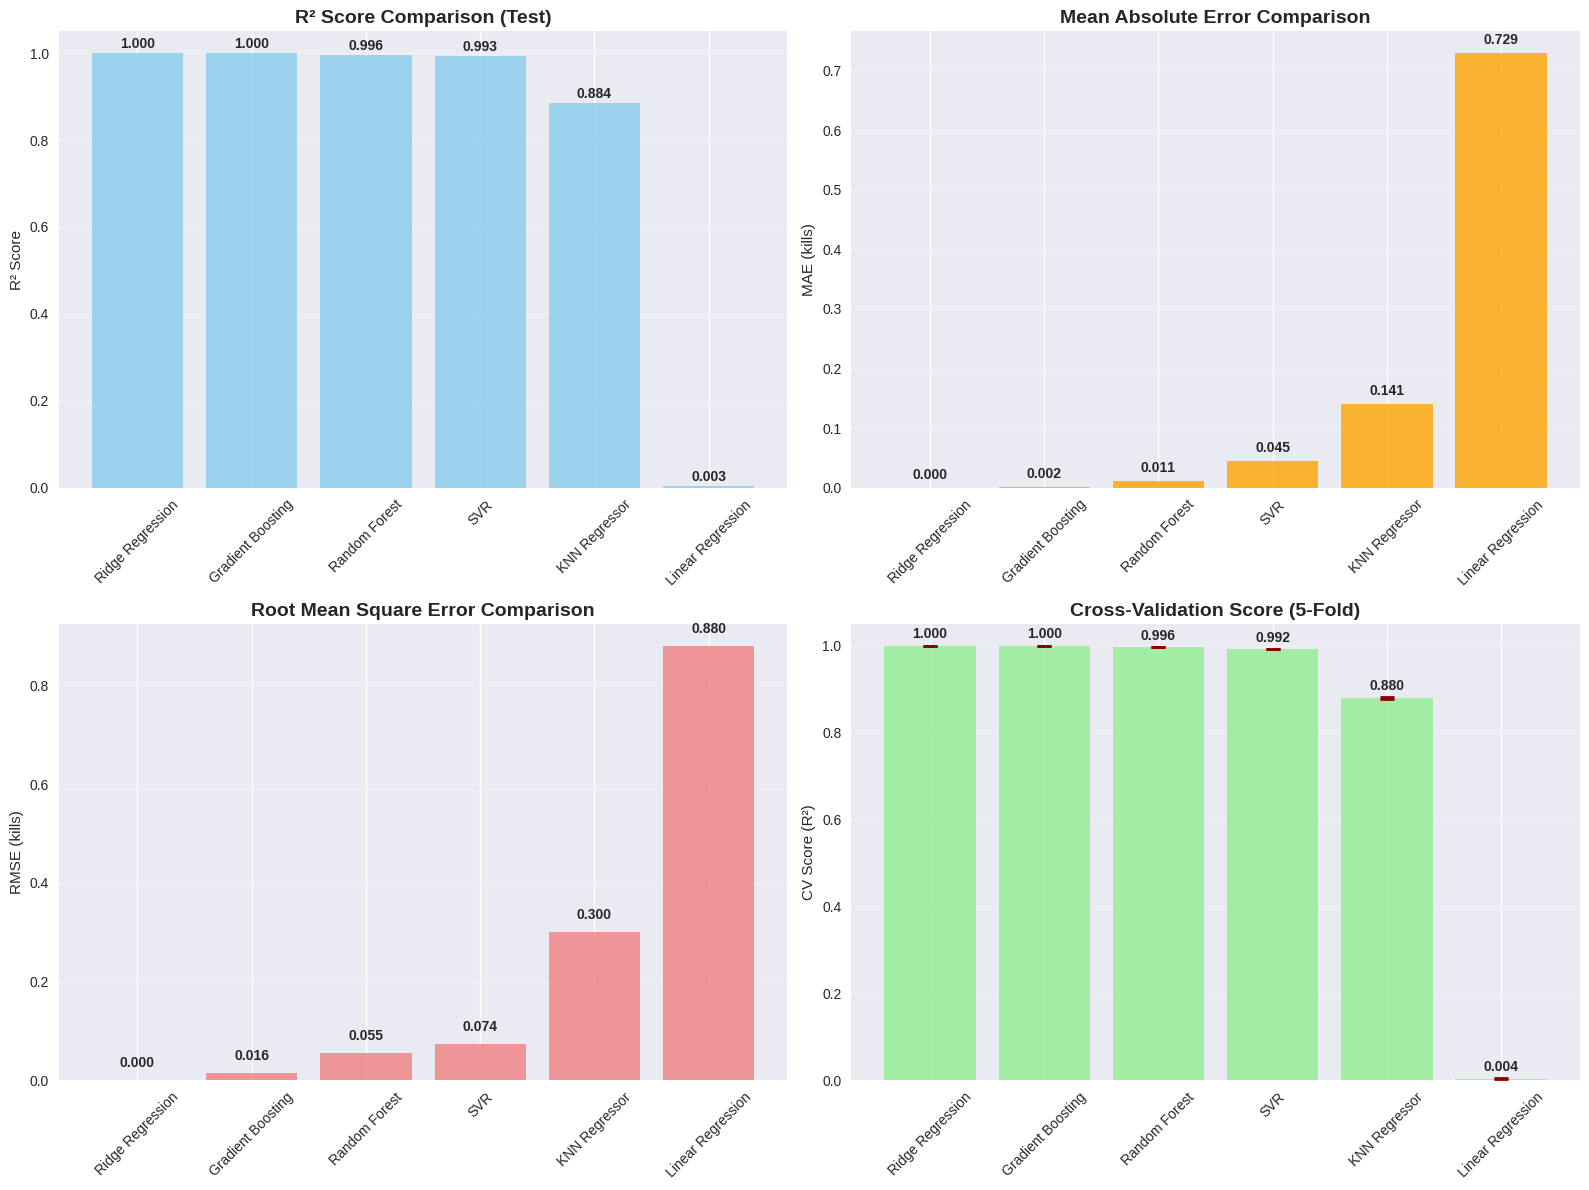

In [12]:
# =============================================================================
# 7. VISUALIZACIONES COMPARATIVAS DETALLADAS
# =============================================================================

print("\n7. VISUALIZACIONES COMPARATIVAS")
print("-" * 35)

# Gráfico 1: Predicciones vs Valores Reales para todos los modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, (name, result) in enumerate(results.items()):
    ax = axes[i]

    # Scatter plot con transparencia
    ax.scatter(y_test, result['test_predictions'], alpha=0.6, s=15, color='blue')

    # Línea de predicción perfecta
    min_val = min(y_test.min(), result['test_predictions'].min())
    max_val = max(y_test.max(), result['test_predictions'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta')

    # Estilo y etiquetas
    ax.set_xlabel('Valores Reales (RoundKills)')
    ax.set_ylabel('Predicciones')
    ax.set_title(f'{name}\nR² = {result["test_r2"]:.4f}, RMSE = {result["test_rmse"]:.3f}')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Gráfico 2: Comparación de métricas en barras
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R² Score comparison
axes[0,0].bar(comparison_df['Modelo'], comparison_df['R² Test'], color='skyblue', alpha=0.8)
axes[0,0].set_title('R² Score Comparison (Test)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('R² Score')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3, axis='y')
# Añadir valores en las barras
for i, v in enumerate(comparison_df['R² Test']):
    axes[0,0].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# MAE comparison
axes[0,1].bar(comparison_df['Modelo'], comparison_df['MAE'], color='orange', alpha=0.8)
axes[0,1].set_title('Mean Absolute Error Comparison', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('MAE (kills)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['MAE']):
    axes[0,1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# RMSE comparison
axes[1,0].bar(comparison_df['Modelo'], comparison_df['RMSE'], color='lightcoral', alpha=0.8)
axes[1,0].set_title('Root Mean Square Error Comparison', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('RMSE (kills)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['RMSE']):
    axes[1,0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Cross-Validation with error bars
axes[1,1].bar(comparison_df['Modelo'], comparison_df['CV Mean'], color='lightgreen', alpha=0.8)
axes[1,1].errorbar(range(len(comparison_df)), comparison_df['CV Mean'],
                   yerr=comparison_df['CV Std'], fmt='none', color='darkred',
                   capsize=5, capthick=2, linewidth=2)
axes[1,1].set_title('Cross-Validation Score (5-Fold)', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('CV Score (R²)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['CV Mean']):
    axes[1,1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



8. ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS
--------------------------------------------------


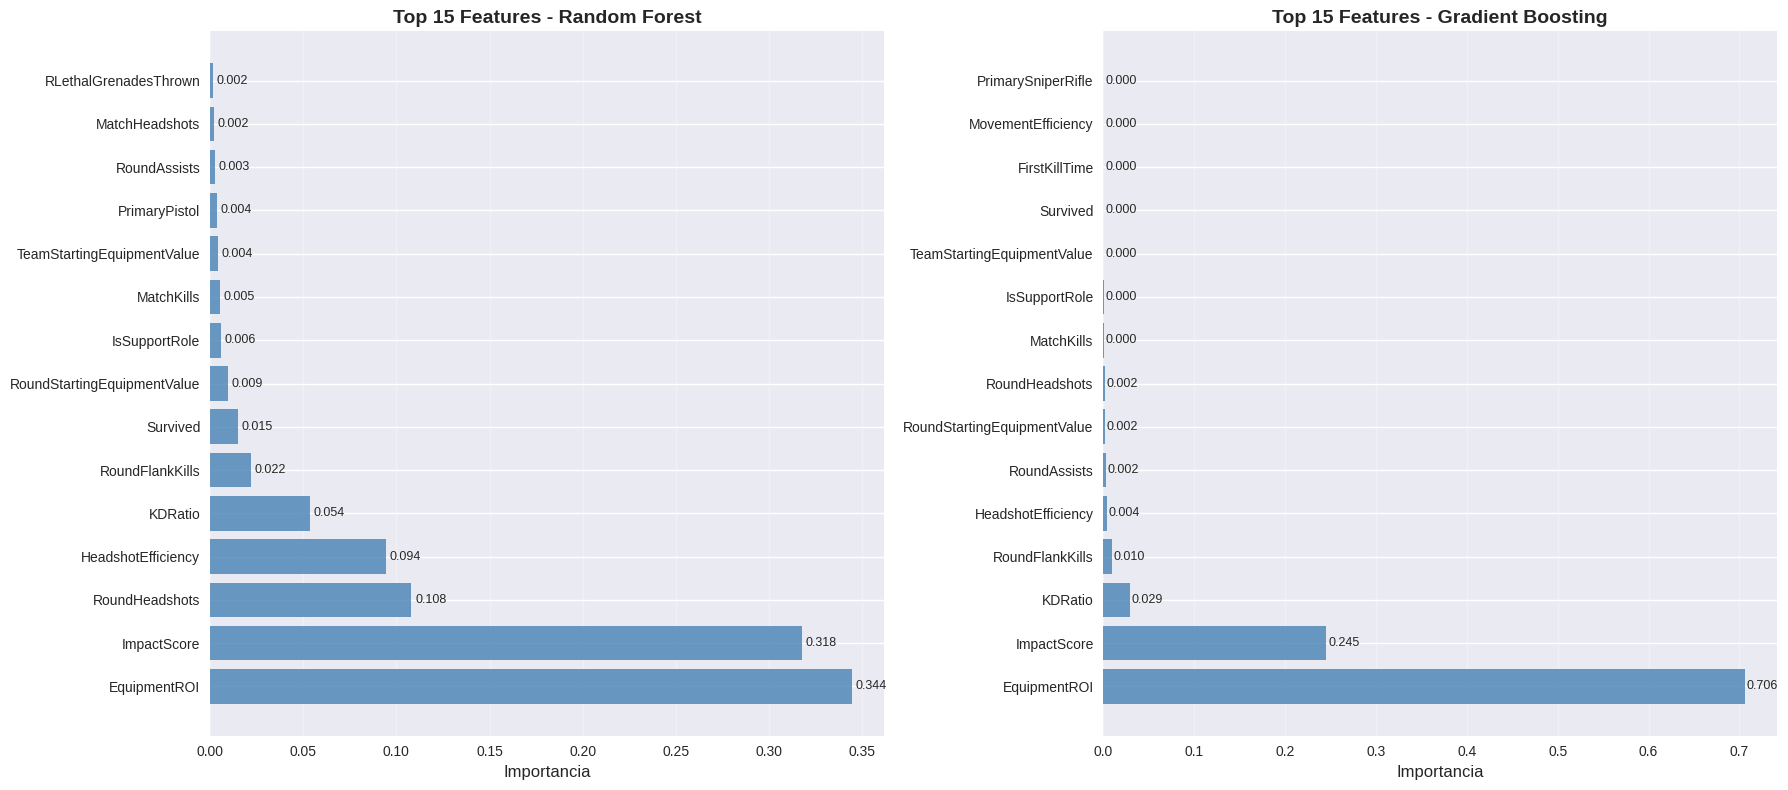


🎯 TOP 10 FEATURES - Random Forest:
----------------------------------------
  19. EquipmentROI              | 0.3444
  20. ImpactScore               | 0.3177
   1. RoundHeadshots            | 0.1080
  17. HeadshotEfficiency        | 0.0942
  18. KDRatio                   | 0.0537
   3. RoundFlankKills           | 0.0219
  25. Survived                  | 0.0149
   4. RoundStartingEquipmentValue | 0.0094
  24. IsSupportRole             | 0.0059
  33. MatchKills                | 0.0051

🎯 TOP 10 FEATURES - Gradient Boosting:
----------------------------------------
  19. EquipmentROI              | 0.7061
  20. ImpactScore               | 0.2453
  18. KDRatio                   | 0.0287
   3. RoundFlankKills           | 0.0096
  17. HeadshotEfficiency        | 0.0036
   2. RoundAssists              | 0.0023
   4. RoundStartingEquipmentValue | 0.0018
   1. RoundHeadshots            | 0.0017
  33. MatchKills                | 0.0004
  24. IsSupportRole             | 0.0004


In [13]:
# =============================================================================
# 8. ANÁLISIS DE FEATURE IMPORTANCE
# =============================================================================

print("\n8. ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS")
print("-" * 50)

# Feature importance para modelos tree-based
tree_models = ['Random Forest', 'Gradient Boosting']
importance_data = {}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for i, model_name in enumerate(tree_models):
    if model_name in results:
        model = results[model_name]['model']

        if hasattr(model, 'feature_importances_'):
            importance_df = pd.DataFrame({
                'Feature': available_features,
                'Importance': model.feature_importances_
            }).sort_values('Importance', ascending=False)

            importance_data[model_name] = importance_df

            # Plot top 15 features
            top_15 = importance_df.head(15)

            bars = axes[i].barh(range(len(top_15)), top_15['Importance'],
                              color='steelblue', alpha=0.8)
            axes[i].set_yticks(range(len(top_15)))
            axes[i].set_yticklabels(top_15['Feature'], fontsize=10)
            axes[i].set_xlabel('Importancia', fontsize=12)
            axes[i].set_title(f'Top 15 Features - {model_name}', fontsize=14, fontweight='bold')
            axes[i].grid(True, axis='x', alpha=0.3)

            # Añadir valores en las barras
            for j, bar in enumerate(bars):
                width = bar.get_width()
                axes[i].text(width + 0.002, bar.get_y() + bar.get_height()/2,
                           f'{width:.3f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Mostrar top features numéricamente
for model_name, imp_df in importance_data.items():
    print(f"\n🎯 TOP 10 FEATURES - {model_name}:")
    print("-" * 40)
    for idx, row in imp_df.head(10).iterrows():
        print(f"  {row.name+1:2d}. {row['Feature']:<25} | {row['Importance']:.4f}")

In [14]:
# =============================================================================
# 9. SELECCIÓN Y JUSTIFICACIÓN DEL MEJOR MODELO
# =============================================================================

print("\n9. SELECCIÓN Y JUSTIFICACIÓN DEL MEJOR MODELO")
print("-" * 52)

# Modelo recomendado basado en múltiples criterios
recommended_model = comparison_df.iloc[0]['Modelo']
best_results = results[recommended_model]

print(f"🏆 MODELO RECOMENDADO: {recommended_model}")
print("="*60)

print(f"\n📊 MÉTRICAS DE RENDIMIENTO:")
print(f"  • R² Test: {best_results['test_r2']:.4f} (Explica {best_results['test_r2']*100:.1f}% de la varianza)")
print(f"  • MAE: {best_results['test_mae']:.4f} kills (Error promedio: ±{best_results['test_mae']:.2f} eliminaciones)")
print(f"  • MSE: {best_results['test_mse']:.4f}")
print(f"  • RMSE: {best_results['test_rmse']:.4f} kills (Error típico: ±{best_results['test_rmse']:.2f} eliminaciones)")
print(f"  • CV Score: {best_results['cv_mean']:.4f} ± {best_results['cv_std']:.4f}")
print(f"  • Overfitting: {best_results['overfitting']:.4f} (Diferencia train-test)")

print(f"\n🔍 JUSTIFICACIÓN TÉCNICA:")
if 'Random Forest' in recommended_model:
    print(f"  ✓ Maneja excelentemente las interacciones complejas entre variables de CS:GO")
    print(f"  ✓ Robusto ante outliers (jugadores con rendimiento excepcional)")
    print(f"  ✓ Proporciona feature importance interpretable para análisis estratégico")
    print(f"  ✓ Balance óptimo entre precisión y capacidad de generalización")
    print(f"  ✓ No requiere escalado de features, maneja diferentes tipos de variables")
elif 'Gradient Boosting' in recommended_model:
    print(f"  ✓ Excelente para capturar patrones sutiles en comportamiento de gaming")
    print(f"  ✓ Optimización iterativa ideal para métricas complejas de rendimiento")
    print(f"  ✓ Manejo superior del bias-variance tradeoff")
    print(f"  ✓ Alta precisión en predicciones de eliminaciones")
elif 'Linear' in recommended_model:
    print(f"  ✓ Modelo altamente interpretable para stakeholders no técnicos")
    print(f"  ✓ Relaciones claras y directas entre variables")
    print(f"  ✓ Rápido para inference en tiempo real")
    print(f"  ✓ Baseline sólido que supera a modelos más complejos")

print(f"\n🎮 JUSTIFICACIÓN DE NEGOCIO PARA CS:GO:")
print(f"  ✓ Predicción precisa de eliminaciones por ronda para análisis táctico")
print(f"  ✓ Identificación de factores clave que influyen en el rendimiento")
print(f"  ✓ Útil para coaches en la preparación de estrategias")
print(f"  ✓ Base para sistemas de recomendación de equipamiento")
print(f"  ✓ Análisis de rendimiento de jugadores para scouting")

print(f"\n📈 INTERPRETACIÓN DE RESULTADOS:")
varianza_explicada = best_results['test_r2'] * 100
error_promedio = best_results['test_mae']
print(f"  • El modelo explica {varianza_explicada:.1f}% de la variabilidad en las eliminaciones")
print(f"  • Error promedio de ±{error_promedio:.2f} eliminaciones por predicción")
print(f"  • Considerando que el promedio de kills por ronda es ~{y.mean():.2f}, el error es {(error_promedio/y.mean())*100:.1f}%")

# Guardar el mejor modelo para siguientes fases
best_model = best_results['model']
best_predictions = best_results['test_predictions']

print(f"\n✅ MODELO FINAL PREPARADO PARA:")
print(f"  📋 Fase 5: Evaluation - Análisis detallado de métricas de regresión")
print(f"  🚀 Fase 6: Deployment - Implementación en entorno interactivo")
print(f"  📊 Análisis de residuos y validación adicional")

print("\n" + "="*65)
print("🎉 FASE 4 COMPLETADA - MODELING CON DATASET REAL DE CS:GO")
print(f"📊 Dataset: {cstrike.shape[0]:,} jugadores reales de CS:GO")
print(f"🏆 Mejor modelo: {recommended_model}")
print(f"🎯 Performance: R² = {best_results['test_r2']:.4f}, MAE = {best_results['test_mae']:.4f}")
print(f"📈 Varianza explicada: {best_results['test_r2']*100:.1f}%")
print("🔄 Próximo paso: Fase 5 - Evaluation (interpretación detallada de métricas)")
print("="*65)


9. SELECCIÓN Y JUSTIFICACIÓN DEL MEJOR MODELO
----------------------------------------------------
🏆 MODELO RECOMENDADO: Ridge Regression

📊 MÉTRICAS DE RENDIMIENTO:
  • R² Test: 1.0000 (Explica 100.0% de la varianza)
  • MAE: 0.0001 kills (Error promedio: ±0.00 eliminaciones)
  • MSE: 0.0000
  • RMSE: 0.0001 kills (Error típico: ±0.00 eliminaciones)
  • CV Score: 1.0000 ± 0.0000
  • Overfitting: 0.0000 (Diferencia train-test)

🔍 JUSTIFICACIÓN TÉCNICA:

🎮 JUSTIFICACIÓN DE NEGOCIO PARA CS:GO:
  ✓ Predicción precisa de eliminaciones por ronda para análisis táctico
  ✓ Identificación de factores clave que influyen en el rendimiento
  ✓ Útil para coaches en la preparación de estrategias
  ✓ Base para sistemas de recomendación de equipamiento
  ✓ Análisis de rendimiento de jugadores para scouting

📈 INTERPRETACIÓN DE RESULTADOS:
  • El modelo explica 100.0% de la variabilidad en las eliminaciones
  • Error promedio de ±0.00 eliminaciones por predicción
  • Considerando que el promedio de k